# 分类回归实战

实战步骤：

1、加载数据集，理解数据集 fashion_minst

2、搭建 class NeuralNetwork 模型

3、设置交叉熵损失函数，SGD 优化器

4、编写评估函数 evaluating

5、编写训练函数 train

6、开始训练 训练多少次

7、绘制损失、准确率曲线

## 1. 数据集理解

In [1]:
import torch
from torchvision import datasets
import matplotlib.pyplot as plt

# 加载数据集
train_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=True)
test_dataset = datasets.FashionMNIST(
    root='./data', train=False, download=True)

# 查看训练集和测试集的形状
print("训练集数量:", len(train_dataset))
print("测试集数量:", len(test_dataset))

# 输出所有标签
labels_map = train_dataset.classes
print("所有标签:", labels_map)
print("标签数量:", len(labels_map))

# 查看第一个样本
print('第一个样本', train_dataset[0])

训练集数量: 60000
测试集数量: 10000
所有标签: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
标签数量: 10
第一个样本 (<PIL.Image.Image image mode=L size=28x28 at 0x1BE9160DA00>, 9)


第一个样本相关信息：
标签索引: 9
标签名称: Ankle boot
像素值类型: <class 'PIL.Image.Image'>
像素值 shape: (28, 28)
第一个样本的28x28像素值：
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 13, 73, 0, 0, 1, 4, 0, 0, 0, 0, 1, 1, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 36, 136, 127, 62, 54, 0, 0, 0, 1, 3, 4, 0, 0, 3]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 102, 204, 176, 134, 144, 123, 23, 0, 0, 0, 0, 12, 10, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 155, 236, 207, 178, 107, 156, 161, 109, 64, 23, 77, 130, 72, 15]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141, 88, 172, 66]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196, 229, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 

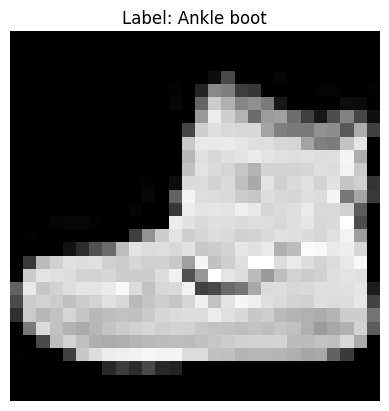

In [2]:
image, label = train_dataset[0]
print("第一个样本相关信息：")
print("标签索引:", label)
print("标签名称:", labels_map[label])
print("像素值类型:", type(image))
print("像素值 shape:", image.size)

# 输出第一个样本的28*28所有像素的值
pixels = list(image.getdata())
pixels_2d = [pixels[i*28:(i+1)*28] for i in range(28)]
print("第一个样本的28x28像素值：")
for row in pixels_2d:
    print(row)

# 打印图像
plt.imshow(image, cmap='gray')
plt.title(f"Label: {labels_map[label]}")
plt.axis('off')
plt.show()

## 2. 数据集预处理

In [3]:
from torch.utils.data import DataLoader
from torchvision import transforms

# 定义数据预处理：将图像转换为Tensor，并进行归一化到[0, 1]
transform = transforms.ToTensor()

# 应用预处理到数据集
train_dataset.transform = transform
test_dataset.transform = transform

# 定义DataLoader参数
batch_size = 64

# 创建DataLoader对数据进行分批
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 示例：打印一个batch的形状
images, labels = next(iter(train_loader))
print("训练集一个batch的图像形状:", images.shape)
print("训练集一个batch的标签形状:", labels.shape)

print("第一个batch中的第一个tensor：")
print(images[0])



训练集一个batch的图像形状: torch.Size([64, 1, 28, 28])
训练集一个batch的标签形状: torch.Size([64])
第一个batch中的第一个tensor：
tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.1373, 0.3373, 0.2196, 0.2275, 0.2118, 0.2980, 0.4235,
          0.3882, 0.5216, 0.4745, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.4118, 0.5333, 0.3529, 0.5137, 0.4745, 0.5569, 0.5490,
          0.6392, 0.7176, 0.9412, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.1216, 0.3373, 0.3059, 0.3373, 0.2706, 0.3451, 0.4745, 0.2941,
          0.3451, 0.3529, 0.7922, 0.0510, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.3216, 0.2941, 0.298

## 3. 搭建模型

In [4]:
from torch import nn

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()  # 展平输入，[batch, 1, 28, 28] -> [batch, 28*28]
        self.fc1 = nn.Linear(28*28, 300)  # 第一全连接层，将784维输入映射到300维
        self.relu1 = nn.ReLU()  # 第一ReLU激活函数
        self.fc2 = nn.Linear(300, 100)  # 第二全连接层，将300维输入映射到100维
        self.relu2 = nn.ReLU()  # 第二ReLU激活函数
        self.fc3 = nn.Linear(100, 10)  # 输出层，将100维输入映射到10个类别

    # 前向传播方法，调用 model(x) 会自动调用 forward(x)
    def forward(self, x):
        x = self.flatten(x)
        # print("经过flatten后形状:", x.shape)
        x = self.fc1(x)
        # print("经过fc1后形状:", x.shape)
        x = self.relu1(x)
        # print("经过relu1后形状:", x.shape)
        x = self.fc2(x)
        # print("经过fc2后形状:", x.shape)
        x = self.relu2(x)
        # print("经过relu2后形状:", x.shape)
        x = self.fc3(x)
        # print("经过fc3后形状:", x.shape)
        return x


In [5]:
# 模型测试

# 随机生成一个数据，形状为 (1, 1, 28, 28)
random_input = torch.randn(1, 1, 28, 28)

# 实例化模型
model = NeuralNetwork()

# 调用模型进行前向传播
output = model(random_input)

print("模型输出：")
print(output)


模型输出：
tensor([[ 0.0833,  0.0257,  0.0849, -0.0252,  0.0322,  0.0849,  0.0396,  0.1273,
         -0.0457,  0.0986]], grad_fn=<AddmmBackward0>)


## 4. 设置损失函数和优化器，定义评估函数

In [6]:
import torch.optim as optim

# 实例化损失函数和优化器
criterion = nn.CrossEntropyLoss()  # 交叉熵损失函数
# 使用随机梯度下降（SGD）优化器，
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    # lr=0.01 是学习率，表示每次参数更新的步长；
    # momentum=0.9 是动量参数，用于加速收敛并减少震荡

# 评估函数 evaluating
def evaluating(model, dataloader, device):
    model.eval()  # 设置为评估模式
    correct = 0  # 正确预测的样本数量
    total = 0    # 样本总数
    loss_sum = 0.0  # 累加损失之和
    with torch.no_grad():  # 关闭自动求导，节省内存与计算
        for images, labels in dataloader:  # 遍历dataloader中的所有批次
            images, labels = images.to(device), labels.to(device)  # 将数据移动到指定的设备
            outputs = model(images)  # 前向传播，计算输出
            loss = criterion(outputs, labels)  # 计算当前批次的损失
            loss_sum += loss.item() * labels.size(0)  # 将损失乘以该批样本数累加到总损失
            predicted = torch.argmax(outputs, dim=1)  # 取概率最大的类别作为预测结果
            total += labels.size(0)  # 累加样本总数
            correct += (predicted == labels).sum().item()  # 累加预测正确的数量
    avg_loss = loss_sum / total  # 计算平均损失
    accuracy = correct / total   # 计算准确率
    return avg_loss, accuracy    # 返回平均损失和准确率


## 5. 模型训练

In [8]:
num_epochs = 10  # 训练的轮数
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

train_losses = []
val_losses = []
val_accuracies = []

# 模型训练
for epoch in range(num_epochs):
    model.train()  # 设置为训练模式
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()           # 梯度清零
        outputs = model(images)         # 前向传播
        loss = criterion(outputs, labels)  # 计算损失
        loss.backward()                 # 反向传播
        optimizer.step()                # 更新参数

        running_loss += loss.item() * labels.size(0)  # 将每个batch的损失乘以batch大小后累加到total running_loss

    train_loss = running_loss / len(train_loader.dataset)  # 计算整个训练集的平均损失
    val_loss, val_acc = evaluating(model, test_loader, device)  # 用验证集评估模型，获得平均损失与准确率

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Train Loss: {train_loss:.4f}, "
          f"Val Loss: {val_loss:.4f}, "
          f"Val Acc: {val_acc:.4f}")



Epoch [1/10], Train Loss: 0.4253, Val Loss: 0.4171, Val Acc: 0.8480
Epoch [2/10], Train Loss: 0.3764, Val Loss: 0.4078, Val Acc: 0.8524
Epoch [3/10], Train Loss: 0.3510, Val Loss: 0.3707, Val Acc: 0.8641
Epoch [4/10], Train Loss: 0.3316, Val Loss: 0.3720, Val Acc: 0.8669
Epoch [5/10], Train Loss: 0.3102, Val Loss: 0.3797, Val Acc: 0.8583
Epoch [6/10], Train Loss: 0.2964, Val Loss: 0.3606, Val Acc: 0.8673
Epoch [7/10], Train Loss: 0.2859, Val Loss: 0.3510, Val Acc: 0.8739
Epoch [8/10], Train Loss: 0.2731, Val Loss: 0.3460, Val Acc: 0.8758
Epoch [9/10], Train Loss: 0.2655, Val Loss: 0.3381, Val Acc: 0.8803
Epoch [10/10], Train Loss: 0.2564, Val Loss: 0.3406, Val Acc: 0.8775


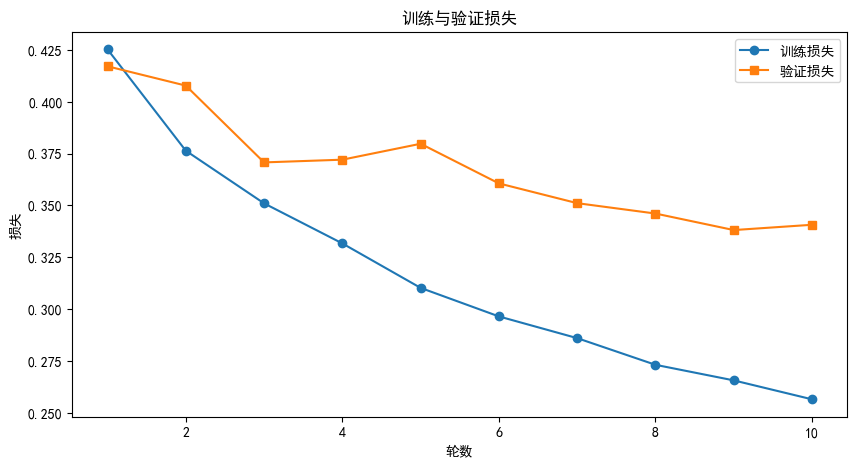

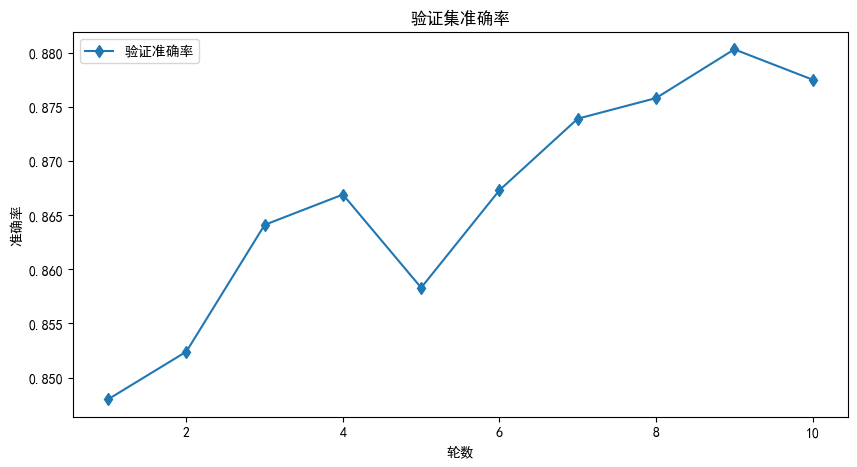

In [11]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号

epochs = range(1, num_epochs + 1)

# 损失曲线
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, 'o-', label='训练损失')
plt.plot(epochs, val_losses, 's-', label='验证损失')
plt.xlabel('轮数')
plt.ylabel('损失')
plt.title('训练与验证损失')
plt.legend()
plt.show()

# 准确率曲线
plt.figure(figsize=(10, 5))
plt.plot(epochs, val_accuracies, 'd-', label='验证准确率')
plt.xlabel('轮数')
plt.ylabel('准确率')
plt.title('验证集准确率')
plt.legend()
plt.show()

